                                            Bike-Sharing Rental                                                            

In [2]:
# importing required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\data analytics\project\Dataset.csv") # read and load the Dataset
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,31-12-2012,springer,2012,12,19,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,11,108,119
17375,17376,31-12-2012,springer,2012,12,20,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,8,81,89
17376,17377,31-12-2012,springer,2012,12,21,No,1,Working Day,Clear,?,0.2576,0.6,0.1642,7,83,90
17377,17378,31-12-2012,springer,2012,12,22,No,1,Working Day,Clear,0.26,0.2727,0.56,0.1343,13,48,61


In [4]:
df=df.drop('instant',axis=1)

In [5]:
df

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,31-12-2012,springer,2012,12,19,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,11,108,119
17375,31-12-2012,springer,2012,12,20,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,8,81,89
17376,31-12-2012,springer,2012,12,21,No,1,Working Day,Clear,?,0.2576,0.6,0.1642,7,83,90
17377,31-12-2012,springer,2012,12,22,No,1,Working Day,Clear,0.26,0.2727,0.56,0.1343,13,48,61


            Exploratory Data Analysis (EDA):

In [7]:
df.shape # retriving the shape of a dataset

(17379, 16)

In [8]:
df.columns  # columns names in dataset

Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [9]:
df.dtypes   # datatypes of an column

dteday        object
season        object
yr            object
mnth          object
hr             int64
holiday       object
weekday        int64
workingday    object
weathersit    object
temp          object
atemp         object
hum           object
windspeed     object
casual        object
registered    object
cnt            int64
dtype: object

In [10]:
df.isnull().sum()  # detecting null values 

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [11]:
df.applymap(lambda x: isinstance(x, str)).sum()  # searching any inconsistance of dataset

dteday        17379
season        17379
yr            17379
mnth          17379
hr                0
holiday       17379
weekday           0
workingday    17379
weathersit    17379
temp          17379
atemp         17379
hum           17379
windspeed     17379
casual        17379
registered    17379
cnt               0
dtype: int64

In [12]:
df.applymap(lambda x: isinstance(x, int)).sum()

dteday            0
season            0
yr                0
mnth              0
hr            17379
holiday           0
weekday       17379
workingday        0
weathersit        0
temp              0
atemp             0
hum               0
windspeed         0
casual            0
registered        0
cnt           17379
dtype: int64

Handling Wrong String Values in Numeric Columns

In [14]:
# Columns expected to be numeric
numeric_cols = ["temp", "atemp", "hum", "windspeed", 
                "casual", "registered", "cnt"]

# Check for non-numeric values
for col in numeric_cols:
    invalid_count = df[col].astype(str).str.contains(r"[A-Za-z?]", regex=True).sum()
    print(f"{col}: {invalid_count} invalid string values")

temp: 11 invalid string values
atemp: 6 invalid string values
hum: 6 invalid string values
windspeed: 5 invalid string values
casual: 1 invalid string values
registered: 1 invalid string values
cnt: 0 invalid string values


In [15]:
# Replace common invalid string entries with NaN
df[numeric_cols] = df[numeric_cols].replace(
    ["?", "NA", "na", "null", "None", "unknown", " "],
    np.nan
)

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

In [16]:
df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

In [17]:
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["mnth"] = pd.to_numeric(df["mnth"], errors="coerce")

In [18]:
df[numeric_cols].isnull().sum()

temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

In [19]:
categorical_cols = [
    "season", "yr", "mnth", "hr",
    "holiday", "weekday", "workingday", "weathersit"
]
for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].astype(str).unique())


invalid_values = ["?", "NA", "na", "null", "None", "unknown", " "]
df[categorical_cols] = df[categorical_cols].replace(invalid_values, np.nan)



season unique values:
['springer' '?' 'summer' 'fall' 'winter']

yr unique values:
['2011.0' 'nan' '2012.0']

mnth unique values:
['1.0' '2.0' '3.0' '4.0' '5.0' '6.0' '7.0' '8.0' '9.0' '10.0' '11.0'
 '12.0' 'nan']

hr unique values:
['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19' '20' '21' '22' '23']

holiday unique values:
['No' 'Yes' '?']

weekday unique values:
['6' '0' '1' '2' '3' '4' '5']

workingday unique values:
['No work' 'Working Day' '?']

weathersit unique values:
['Clear' 'Mist' '?' 'Light Snow' 'Heavy Rain']


In [20]:
df.isnull().sum()

dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

Handle the Missing Values (Imputation)

Medium imputation for the numerical columns

 robust to outliers

In [23]:
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

Mode imputation for the categorical columns

Preserves category distribution

In [25]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [26]:
df.isnull().sum()

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [27]:
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

Duplicate rows: 0


Outlier Detection using Boxplot

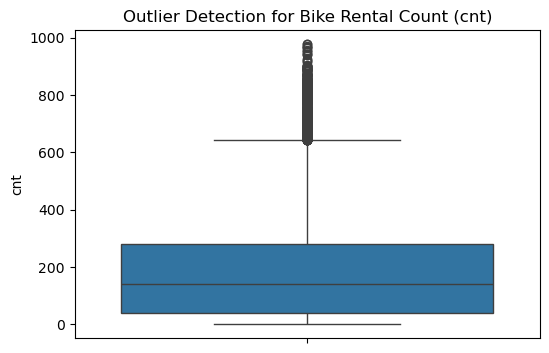

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["cnt"])
plt.title("Outlier Detection for Bike Rental Count (cnt)")
plt.show()

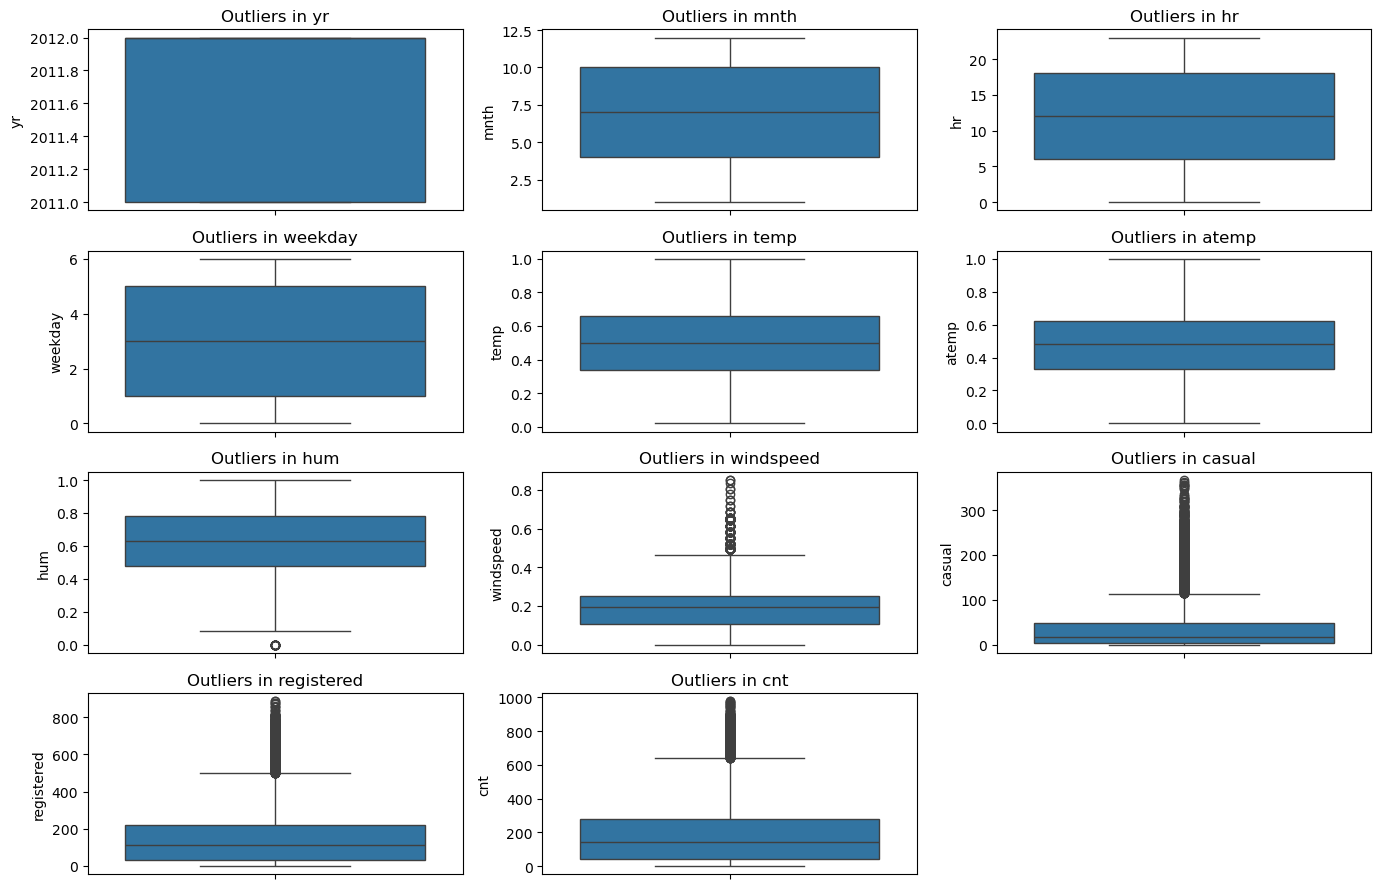

In [30]:
numerical_features = df.select_dtypes(include='number')
plt.figure(figsize=(14,9))
for i, col in enumerate(numerical_features):
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Outliers in {col}")

plt.tight_layout()
plt.show()


In [31]:
def detect_outliers_iqr(df, cols):
    outliers_dict = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_dict[col] = outliers
    return outliers_dict

def treat_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower_bound, upper_bound)
    return df

# multiple columns
columns_to_check =df.select_dtypes(include='number')

# Detect outliers in multiple columns
outliers_dict = detect_outliers_iqr(df, columns_to_check)
for col, outliers in outliers_dict.items():
    print(f"Outliers in column {col}:")
    print(outliers)

# Treat outliers by capping in multiple columns
df = treat_outliers_iqr(df, columns_to_check)


Outliers in column yr:
Empty DataFrame
Columns: [dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, casual, registered, cnt]
Index: []
Outliers in column mnth:
Empty DataFrame
Columns: [dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, casual, registered, cnt]
Index: []
Outliers in column hr:
Empty DataFrame
Columns: [dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, casual, registered, cnt]
Index: []
Outliers in column weekday:
Empty DataFrame
Columns: [dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, casual, registered, cnt]
Index: []
Outliers in column temp:
Empty DataFrame
Columns: [dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, casual, registered, cnt]
Index: []
Outliers in column atemp:
Empty DataFrame
Columns: [dteday, season

<Axes: >

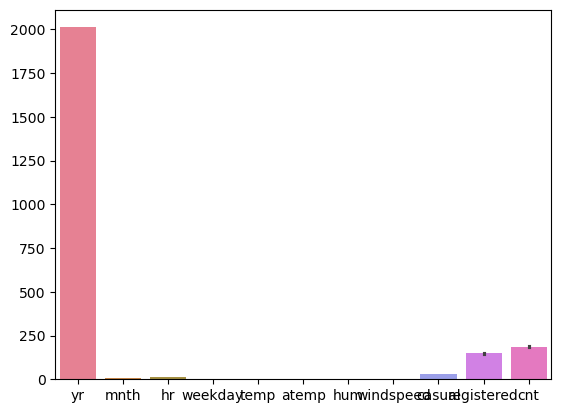

In [32]:
sns.barplot(df)

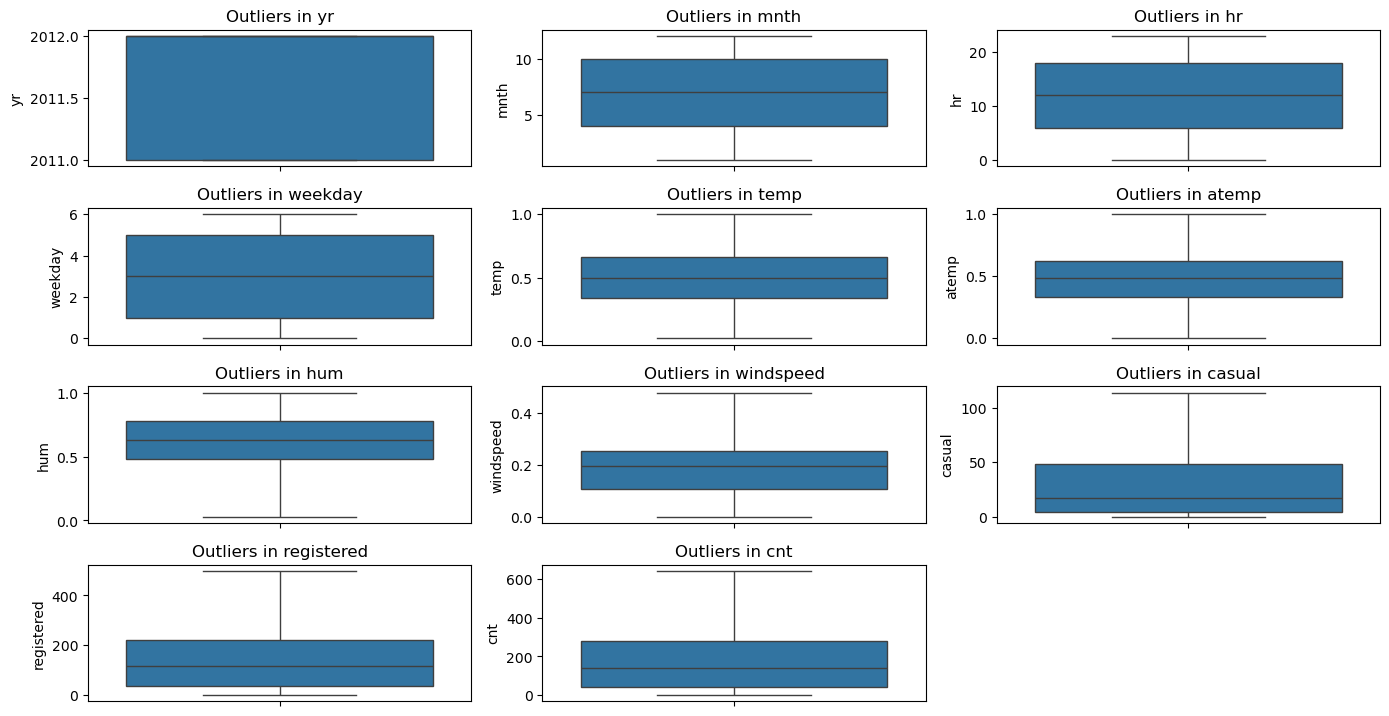

In [33]:
numerical_features = df.select_dtypes(include='number')
plt.figure(figsize=(14,9))
for i, col in enumerate(numerical_features):
    plt.subplot(5, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Outliers in {col}")

plt.tight_layout()
plt.show()

                        	Data Visualization:

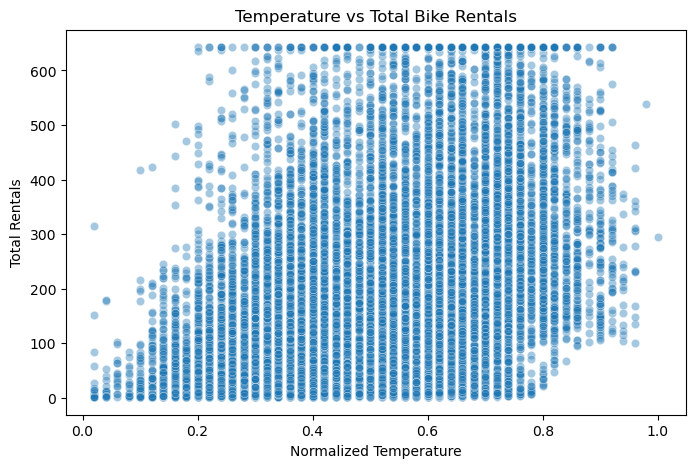

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="temp", y="cnt", alpha=0.4)
plt.title("Temperature vs Total Bike Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Rentals")
plt.show()


Bike rentals increase with comfortable temperature, indicating weather-driven demand.

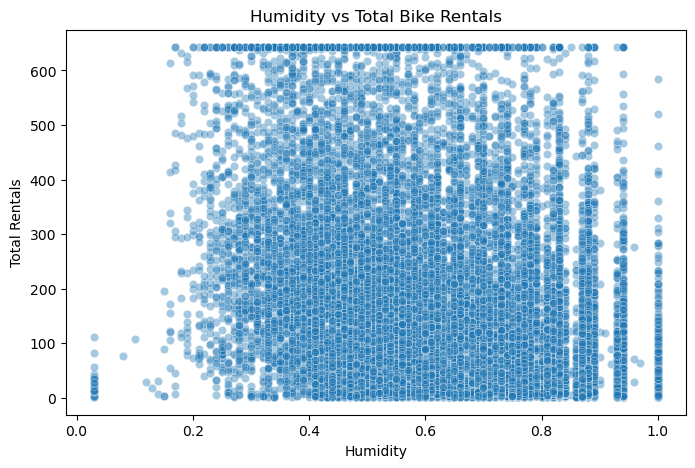

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="hum", y="cnt", alpha=0.4)
plt.title("Humidity vs Total Bike Rentals")
plt.xlabel("Humidity")
plt.ylabel("Total Rentals")
plt.show()

Higher humidity generally reduces rental demand

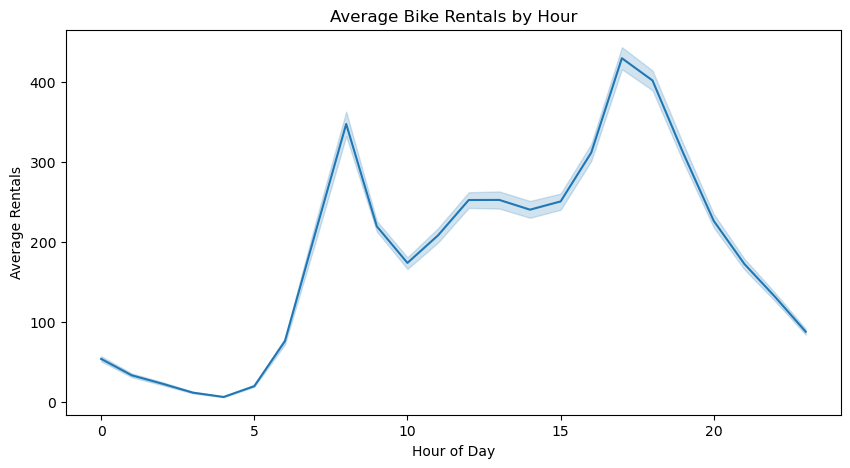

In [39]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="hr", y="cnt", estimator="mean")
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.show()

Clear morning and evening peaks represent commuting patterns.

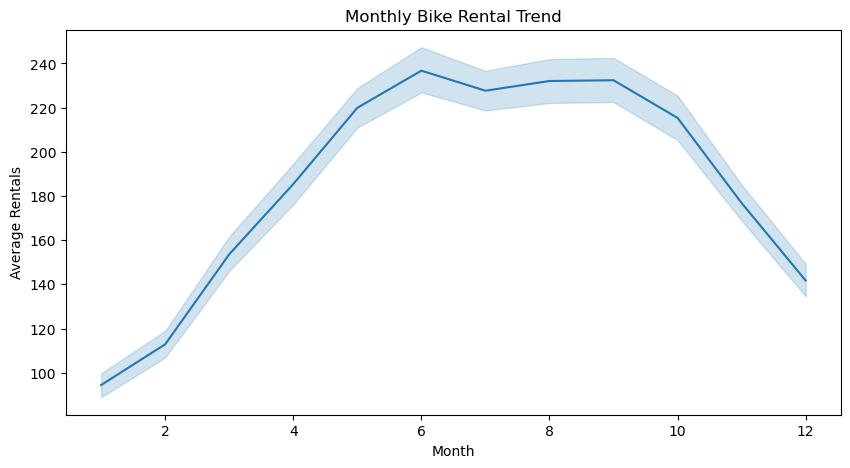

In [41]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="mnth", y="cnt", estimator="mean")
plt.title("Monthly Bike Rental Trend")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.show()

Shows seasonal demand variation.

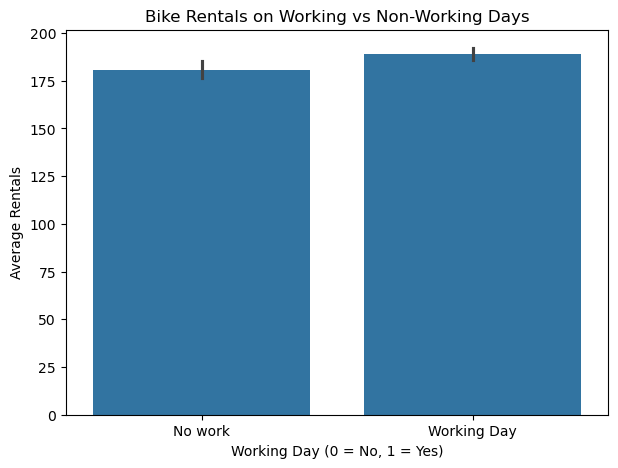

In [43]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x="workingday", y="cnt", estimator="mean")
plt.title("Bike Rentals on Working vs Non-Working Days")
plt.xlabel("Working Day (0 = No, 1 = Yes)")
plt.ylabel("Average Rentals")
plt.show()

Working days show higher demand due to office commuting.

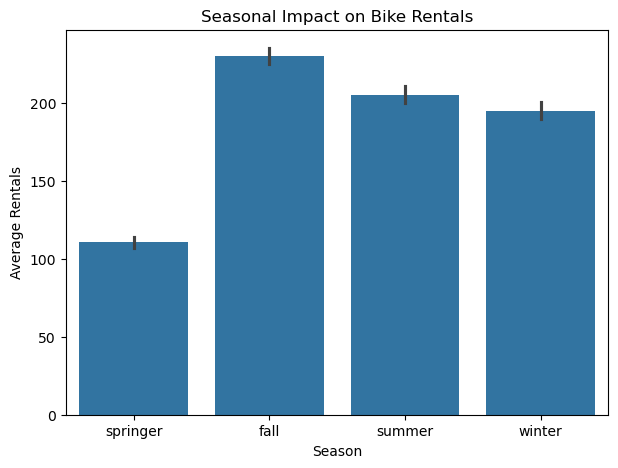

In [45]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x="season", y="cnt", estimator="mean")
plt.title("Seasonal Impact on Bike Rentals")
plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.show()

            Time Series Plot – Daily Rental Trend

C:\Users\Suresh\AppData\Local\Temp\ipykernel_12356\1135512148.py:2: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df["dteday"] = pd.to_datetime(df["dteday"])


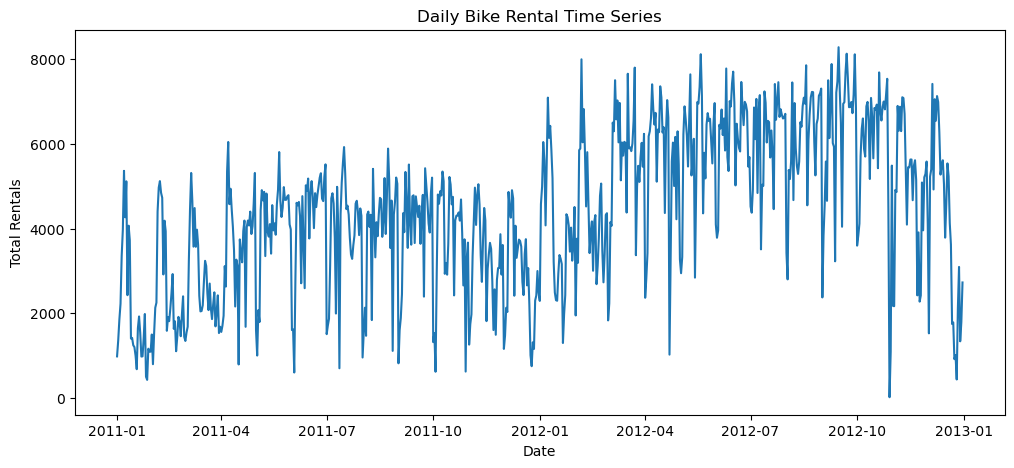

In [47]:
# Ensure date is datetime
df["dteday"] = pd.to_datetime(df["dteday"])

daily_rentals = df.groupby("dteday")["cnt"].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_rentals)
plt.title("Daily Bike Rental Time Series")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.show()


In [48]:
z=df.corr(numeric_only=True)
z

,yr,mnth,hr,weekday,temp,atemp,hum,windspeed,casual,registered,cnt
yr,1.000000,-0.010776,-0.003776,-0.004542,0.041164,0.039425,-0.083695,-0.009185,0.136675,0.246863,0.246288
mnth,-0.010776,1.000000,-0.005865,0.010518,0.202579,0.208871,0.164429,-0.133732,0.088340,0.124850,0.121279
hr,-0.003776,-0.005865,1.000000,-0.003498,0.137708,0.133940,-0.276689,0.137728,0.372558,0.402129,0.404993
weekday,-0.004542,0.010518,-0.003498,1.000000,-0.002015,-0.008678,-0.037121,0.010406,0.022385,0.025742,0.028075
temp,0.041164,0.202579,0.137708,-0.002015,1.000000,0.987010,-0.069894,-0.019952,0.536325,0.348681,0.410833
atemp,0.039425,0.208871,0.133940,-0.008678,0.987010,1.000000,-0.052018,-0.059303,0.529245,0.346401,0.407480
hum,-0.083695,0.164429,-0.276689,-0.037121,-0.069894,-0.052018,1.000000,-0.290654,-0.384290,-0.291401,-0.329833
windspeed,-0.009185,-0.133732,0.137728,0.010406,-0.019952,-0.059303,-0.290654,1.000000,0.103932,0.094248,0.100964
casual,0.136675,0.088340,0.372558,0.022385,0.536325,0.529245,-0.384290,0.103932,1.000000,0.610897,0.750258
registered,0.246863,0.124850,0.402129,0.025742,0.348681,0.346401,-0.291401,0.094248,0.610897,1.000000,0.973345


<Axes: >

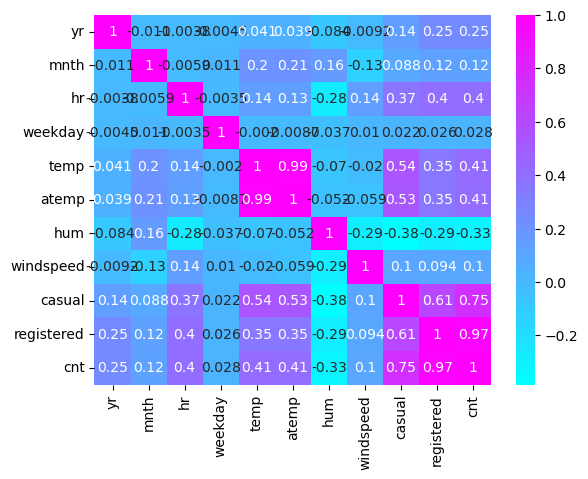

In [49]:
sns.heatmap(z,cmap='cool',annot=True)

        Generating New Features from Existing Ones

In [51]:
# Peak hour feature (morning & evening commute)
df["is_peak_hour"] = df["hr"].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)

In [52]:
# Weekend feature
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x in [0, 6] else 0)

Created new features using time-based and domain knowledge

In [54]:
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,is_peak_hour,is_weekend
0,2011-01-01,springer,2011.0,1.0,0,No,6,No work,Clear,0.24,0.2879,0.81,0.0,3.0,13.0,16.0,0,1
1,2011-01-01,springer,2011.0,1.0,1,No,6,No work,Clear,0.22,0.2727,0.80,0.0,8.0,32.0,40.0,0,1
2,2011-01-01,springer,2011.0,1.0,2,No,6,No work,Clear,0.22,0.2727,0.63,0.0,5.0,27.0,32.0,0,1
3,2011-01-01,springer,2011.0,1.0,3,No,6,No work,Clear,0.24,0.2879,0.75,0.0,3.0,10.0,13.0,0,1
4,2011-01-01,springer,2011.0,1.0,4,No,6,No work,Clear,0.24,0.2879,0.75,0.0,0.0,1.0,1.0,0,1


In [55]:
df.shape

(17379, 18)

In [56]:
df.columns

Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'is_peak_hour', 'is_weekend'],
      dtype='object')

Encoding the categorical columns using one-hot encoding

In [58]:
# Peak hour feature
df["is_peak_hour"] = df["hr"].apply(
    lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0
)

# Weekend feature
df["is_weekend"] = df["weekday"].apply(
    lambda x: 1 if x in [0, 6] else 0
)

# Weather comfort feature
df["weather_comfort"] = df["temp"] * (1 - df["hum"])


In [59]:
categorical_cols = [
    "season",
    "weekday",
    "holiday",
    "workingday",
    "weathersit",
    "is_peak_hour",
    "is_weekend"
]


In [60]:
numerical_cols = [
    "yr",
    "mnth",
    "hr",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "weather_comfort"
]


In [61]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_cat = encoder.fit_transform(df[categorical_cols])

encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(categorical_cols)
)


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_num = scaler.fit_transform(df[numerical_cols])

scaled_num_df = pd.DataFrame(
    scaled_num,
    columns=numerical_cols
)


In [63]:
X_final = pd.concat([scaled_num_df, encoded_cat_df], axis=1)
y = df["cnt"]

In [64]:
X_final.head()

,yr,mnth,hr,temp,atemp,hum,windspeed,weather_comfort,season_springer,season_summer,...,weekday_4,weekday_5,weekday_6,holiday_Yes,workingday_Working Day,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,is_peak_hour_1,is_weekend_1
0,-1.00525,-1.610428,-1.670004,-1.336047,-1.094064,0.947991,-1.596714,-1.060976,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.00525,-1.610428,-1.525374,-1.439966,-1.182542,0.896119,-1.596714,-1.072905,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-1.00525,-1.610428,-1.380744,-1.439966,-1.182542,0.014282,-1.596714,-0.794057,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-1.00525,-1.610428,-1.236115,-1.336047,-1.094064,0.636755,-1.596714,-0.953612,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.00525,-1.610428,-1.091485,-1.336047,-1.094064,0.636755,-1.596714,-0.953612,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [65]:
encoder.categories_

[array(['fall', 'springer', 'summer', 'winter'], dtype=object),
 array([0, 1, 2, 3, 4, 5, 6], dtype=int64),
 array(['No', 'Yes'], dtype=object),
 array(['No work', 'Working Day'], dtype=object),
 array(['Clear', 'Heavy Rain', 'Light Snow', 'Mist'], dtype=object),
 array([0, 1], dtype=int64),
 array([0, 1], dtype=int64)]

In [66]:
X_final.columns

Index(['yr', 'mnth', 'hr', 'temp', 'atemp', 'hum', 'windspeed',
       'weather_comfort', 'season_springer', 'season_summer', 'season_winter',
       'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5',
       'weekday_6', 'holiday_Yes', 'workingday_Working Day',
       'weathersit_Heavy Rain', 'weathersit_Light Snow', 'weathersit_Mist',
       'is_peak_hour_1', 'is_weekend_1'],
      dtype='object')

In [67]:
df.describe()

,yr,mnth,hr,weekday,temp,atemp,hum,windspeed,casual,registered,cnt,is_peak_hour,is_weekend,weather_comfort
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2011.502618,6.537373,11.546752,3.003683,0.497133,0.475854,0.627247,0.188679,31.158122,148.648656,186.361327,0.251280,0.288509,0.187901
std,0.500008,3.438546,6.914405,2.005771,0.192464,0.171800,0.192785,0.118170,34.813309,135.350168,171.931168,0.433762,0.453082,0.134127
min,2011.000000,1.000000,0.000000,0.000000,0.020000,0.000000,0.030000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2011.000000,4.000000,6.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,0.000000,0.000000,0.085400
50%,2012.000000,7.000000,12.000000,3.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,0.000000,0.000000,0.153000
75%,2012.000000,10.000000,18.000000,5.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,1.000000,1.000000,0.260400
max,2012.000000,12.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.477500,114.000000,499.000000,642.500000,1.000000,1.000000,0.810000


In [68]:
X_final.describe()

,yr,mnth,hr,temp,atemp,hum,windspeed,weather_comfort,season_springer,season_summer,...,weekday_4,weekday_5,weekday_6,holiday_Yes,workingday_Working Day,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,is_peak_hour_1,is_weekend_1
count,1.737900e+04,1.737900e+04,1.737900e+04,1.737900e+04,1.737900e+04,1.737900e+04,1.737900e+04,1.737900e+04,17379.000000,17379.000000,...,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,-1.378581e-13,-5.233297e-17,-7.456426e-17,1.308324e-17,-4.252054e-16,-1.553635e-16,2.453108e-16,-3.270811e-17,0.243742,0.253697,...,0.142183,0.143104,0.144542,0.028770,0.682836,0.000173,0.081650,0.261292,0.251280,0.288509
std,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,0.429351,0.435139,...,0.349248,0.350189,0.351649,0.167165,0.465385,0.013138,0.273839,0.439352,0.433762,0.453082
min,-1.005250e+00,-1.610428e+00,-1.670004e+00,-2.479152e+00,-2.769902e+00,-3.098082e+00,-1.596714e+00,-1.400962e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.005250e+00,-7.379415e-01,-8.022254e-01,-8.164539e-01,-8.297955e-01,-7.638087e-01,-7.123711e-01,-7.642335e-01,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.947774e-01,1.345454e-01,6.555318e-02,1.489506e-02,5.207131e-02,1.428224e-02,4.503259e-02,-2.602185e-01,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.947774e-01,1.007032e+00,9.333318e-01,8.462440e-01,8.460424e-01,7.923732e-01,5.502504e-01,5.405389e-01,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,9.947774e-01,1.588690e+00,1.656481e+00,2.612860e+00,3.051000e+00,1.933573e+00,2.444183e+00,4.638270e+00,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



<h1>MODEL BUILDING</h1>

<h3> MODEL:-1 LINEAR REGRESSION <h3>

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [72]:
x = X_final
y = y
            # Prepare Features and Target

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (13903, 24)
Testing data shape: (3476, 24)


In [74]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)
                                # Training Linear Regression Model

LinearRegression()

In [75]:
y_pred = lr_model.predict(X_test)
   # predicting variable Making predictions

Model Evaluation

In [77]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Linear Regression Performance:
MAE  : 82.316
RMSE : 107.576
R²   : 0.593


<h4>Interpretation: 
    
Linear Regression serves as a baseline model to understand the linear relationship
between features and bike rental demand. The results provide a reference point
for comparing more complex models such as tree-based and ensemble methods.<h4>

<h3> MODEL:2 Ridge Regression Model<h3>

Ridge Regression is a regularized linear model that:

Reduces overfitting

Handles multicollinearity (important since we  have many features)

Improves stability compared to plain Linear Regression

Ridge regression introduces L2 regularization to penalize large coefficients and improve generalization

In [82]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [83]:
ridge_model = Ridge(alpha=1.0)  # alpha = regularization strength

ridge_model.fit(X_train, y_train)
                                    # Train Ridge Regression Model

Ridge()

In [84]:
y_pred_ridge = ridge_model.predict(X_test)  # making predictions


Evaluate Ridge Regression

In [86]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance:")
print(f"MAE  : {mae_ridge:.3f}")
print(f"RMSE : {rmse_ridge:.3f}")
print(f"R²   : {r2_ridge:.3f}")

Ridge Regression Performance:
MAE  : 82.312
RMSE : 107.574
R²   : 0.593


<h5>Interpretation:
    
Ridge Regression improves upon Linear Regression by applying L2 regularization,<b>

which reduces the impact of multicollinearity and stabilizes model coefficients.<b>

This leads to better generalization performance on unseen data.</h5>

<h4> MODEL 3 Lasso Regression Model<h4>

Lasso Regression:

Uses L1 regularization

Can shrink some coefficients to exactly zero

Helps identify important features

Reduces model complexity

Lasso regression performs both regularization and feature selection, making it useful when dealing with high-dimensional data.

In [91]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [92]:
lasso_model = Lasso(alpha=0.001, max_iter=10000)

lasso_model.fit(X_train, y_train)

Lasso(alpha=0.001, max_iter=10000)

In [93]:
y_pred_lasso = lasso_model.predict(X_test)  # make predictons

Evaluate Lasso Regression

In [95]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Performance:")
print(f"MAE  : {mae_lasso:.3f}")
print(f"RMSE : {rmse_lasso:.3f}")
print(f"R²   : {r2_lasso:.3f}")

Lasso Regression Performance:
MAE  : 82.314
RMSE : 107.575
R²   : 0.593


Feature Selection Insight

In [97]:
# Number of selected (non-zero) features
selected_features = np.sum(lasso_model.coef_ != 0)
total_features = len(lasso_model.coef_)

print(f"Selected features: {selected_features} out of {total_features}")

Selected features: 23 out of 24


<h5>
    
Interpretation:

Lasso Regression applies L1 regularization, which forces less important feature<b>

coefficients to zero. This helps in feature selection and reduces model complexity,<b>

making the model more interpretable compared to Ridge Regression.<h5>

<h4>
 MODEL 4 Decision Tree Regressor
<h4>

Decision Tree:

Captures non-linear relationships

Works well with time & weather features

Easy to interpret

Handles numeric features like hr, month, yr naturally

Decision Trees split data based on feature values and can model complex, non-linear patterns in bike rental demand

In [101]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [102]:
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)

In [103]:
y_pred_dt = dt_model.predict(X_test)

In [104]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance:")
print(f"MAE  : {mae_dt:.3f}")
print(f"RMSE : {rmse_dt:.3f}")
print(f"R²   : {r2_dt:.3f}")

Decision Tree Performance:
MAE  : 32.312
RMSE : 53.023
R²   : 0.901


In [105]:
feature_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": dt_model.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
)

feature_importance.head(10)


,Feature,Importance
2,hr,0.512682
3,temp,0.120671
18,workingday_Working Day,0.104686
0,yr,0.085771
22,is_peak_hour_1,0.084738
7,weather_comfort,0.017512
20,weathersit_Light Snow,0.011047
4,atemp,0.010986
1,mnth,0.010309
10,season_winter,0.009129


<h5>
    
Interpretation:

The Decision Tree model captures non-linear relationships between features

and bike rental demand. Time-related features such as hour and month,

along with weather conditions, play a significant role in demand prediction.<h5>

<h4> model 5 Random Forest Regressor<h4>

Random Forest:

Is an ensemble of decision trees

Reduces overfitting

Handles non-linear relationships

Works very well with time + weather features

Random Forest improves prediction accuracy by combining multiple decision trees and averaging their results, leading to better generalization

In [109]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [110]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, min_samples_split=10,
                      n_jobs=-1, random_state=42)

In [111]:
y_pred_rf = rf_model.predict(X_test)


In [112]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE  : {mae_rf:.3f}")
print(f"RMSE : {rmse_rf:.3f}")
print(f"R²   : {r2_rf:.3f}")


Random Forest Performance:
MAE  : 25.214
RMSE : 41.393
R²   : 0.940


In [113]:
rf_feature_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf_model.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
)

rf_feature_importance.head(10)

,Feature,Importance
2,hr,0.502583
3,temp,0.094777
18,workingday_Working Day,0.083425
0,yr,0.082986
22,is_peak_hour_1,0.081809
7,weather_comfort,0.049665
4,atemp,0.021676
23,is_weekend_1,0.017013
1,mnth,0.014977
8,season_springer,0.013270


<h5>
    
Interpretation:

Random Forest Regression significantly improves performance by combining

multiple decision trees. It effectively captures complex interactions

between time and weather features, resulting in better prediction accuracy
compared to individual tree models<h5>

<h4> MODEL 6 Gradient Boosting Regressor <h4>

Gradient Boosting:

Builds trees sequentially

Each new tree corrects errors of the previous one

Handles complex non-linear relationships

Often outperforms Random Forest on structured data

Gradient Boosting improves prediction accuracy by iteratively learning from previous model errors

In [117]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [118]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gbr_model.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200,
                          random_state=42)

In [119]:
y_pred_gbr = gbr_model.predict(X_test)


In [120]:
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Performance:")
print(f"MAE  : {mae_gbr:.3f}")
print(f"RMSE : {rmse_gbr:.3f}")
print(f"R²   : {r2_gbr:.3f}")

Gradient Boosting Performance:
MAE  : 27.045
RMSE : 41.323
R²   : 0.940


<h5>

Interpretation:

Gradient Boosting Regressor delivers strong predictive performance by

sequentially correcting errors made by previous models. Its ability to

capture complex non-linear interactions makes it highly suitable for
bike rental demand prediction<h5>

<h5> model comparision table<h5>

In [123]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],
    "MAE": [
        mae,
        mae_ridge,
        mae_lasso,
        mae_dt,
        mae_rf,
        mae_gbr
    ],
    "RMSE": [
        rmse,
        rmse_ridge,
        rmse_lasso,
        rmse_dt,
        rmse_rf,
        rmse_gbr
    ],
    "R² Score": [
        r2,
        r2_ridge,
        r2_lasso,
        r2_dt,
        r2_rf,
        r2_gbr
    ]
})

model_comparison


,Model,MAE,RMSE,R² Score
0,Linear Regression,82.315628,107.576062,0.593034
1,Ridge Regression,82.312274,107.573693,0.593052
2,Lasso Regression,82.313702,107.574658,0.593045
3,Decision Tree Regressor,32.311617,53.022943,0.901132
4,Random Forest Regressor,25.213504,41.392937,0.939747
5,Gradient Boosting Regressor,27.045179,41.323021,0.939950


In [124]:
model_comparison.sort_values(by="RMSE")

,Model,MAE,RMSE,R² Score
5,Gradient Boosting Regressor,27.045179,41.323021,0.939950
4,Random Forest Regressor,25.213504,41.392937,0.939747
3,Decision Tree Regressor,32.311617,53.022943,0.901132
1,Ridge Regression,82.312274,107.573693,0.593052
2,Lasso Regression,82.313702,107.574658,0.593045
0,Linear Regression,82.315628,107.576062,0.593034


In [125]:
best_model = model_comparison.loc[model_comparison["RMSE"].idxmin()]
best_model

Model       Gradient Boosting Regressor
MAE                           27.045179
RMSE                          41.323021
R² Score                        0.93995
Name: 5, dtype: object

<h4>Hyperparameter Tuning<h4>

Hyperparameter tuning is performed to optimize model performance by identifying the best combination of parameters while ensuring proper generalization.

    In this project, Decision Tree, Random Forest, and Gradient Boosting Regression models are tuned using GridSearchCV with cross-validation.

Hyperparameters control model complexity and learning behavior.
Proper tuning helps to:

Prevent overfitting (model too complex)

Prevent underfitting (model too simple)

Improve generalization on unseen data

<h4>Hyperparameter Tuning – Decision Tree Regressor<h4>

In [130]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

In [131]:
dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_root_mean_squared_error')

In [132]:
best_dt_model = dt_grid.best_estimator_

print("Best Decision Tree Parameters:", dt_grid.best_params_)

Best Decision Tree Parameters: {'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 2}


<h4>Hyperparameter Tuning – Random Forest Regressor<h4>

In [134]:
from sklearn.ensemble import RandomForestRegressor

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [2, 5]
}


In [135]:
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 15, 20], 'min_samples_leaf': [2, 5],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [136]:
best_rf_model = rf_grid.best_estimator_

print("Best Random Forest Parameters:", rf_grid.best_params_)


Best Random Forest Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


<h4>Hyperparameter Tuning – Gradient Boosting Regressor<h4>

In [138]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}


In [139]:
gbr_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gbr_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gbr_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error')

In [140]:
best_gbr_model = gbr_grid.best_estimator_

print("Best Gradient Boosting Parameters:", gbr_grid.best_params_)


Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


<h4>Model Evaluation After Hyperparameter Tuning<h4>

In [142]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

dt_tuned_results = evaluate_model(best_dt_model, X_test, y_test)
rf_tuned_results = evaluate_model(best_rf_model, X_test, y_test)
gbr_tuned_results = evaluate_model(best_gbr_model, X_test, y_test)

dt_tuned_results, rf_tuned_results, gbr_tuned_results


({'MAE': 29.758252308248597,
  'RMSE': 49.35374585643529,
  'R2': 0.914342159512366},
 {'MAE': 23.652480219104792,
  'RMSE': 39.348189465370446,
  'R2': 0.9455526949918008},
 {'MAE': 24.752920324424892,
  'RMSE': 38.471545298992424,
  'R2': 0.9479517487172165})

In [143]:
tuned_model_comparison = pd.DataFrame([
    {
        "Model": "Decision Tree (Tuned)",
        "MAE": dt_tuned_results["MAE"],
        "RMSE": dt_tuned_results["RMSE"],
        "R² Score": dt_tuned_results["R2"]
    },
    {
        "Model": "Random Forest (Tuned)",
        "MAE": rf_tuned_results["MAE"],
        "RMSE": rf_tuned_results["RMSE"],
        "R² Score": rf_tuned_results["R2"]
    },
    {
        "Model": "Gradient Boosting (Tuned)",
        "MAE": gbr_tuned_results["MAE"],
        "RMSE": gbr_tuned_results["RMSE"],
        "R² Score": gbr_tuned_results["R2"]
    }
])

tuned_model_comparison


,Model,MAE,RMSE,R² Score
0,Decision Tree (Tuned),29.758252,49.353746,0.914342
1,Random Forest (Tuned),23.652480,39.348189,0.945553
2,Gradient Boosting (Tuned),24.752920,38.471545,0.947952


In [144]:
tuned_model_comparison.sort_values(by="R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
2,Gradient Boosting (Tuned),24.752920,38.471545,0.947952
1,Random Forest (Tuned),23.652480,39.348189,0.945553
0,Decision Tree (Tuned),29.758252,49.353746,0.914342


<h4>
    After hyperparameter tuning, 
    
    model performance was evaluated and summarized in a comparison table. 
    Ensemble models showed improved performance compared to untuned versions
<h4>

Multiple regression models were implemented, including Linear Regression, Ridge Regression, Lasso Regression, Decision Tree, Random Forest, and Gradient Boosting, to satisfy comparative analysis requirements. Linear and regularized models served as baseline references, while tree-based and ensemble models captured complex non-linear relationships present in the data.

Hyperparameter tuning using GridSearchCV with cross-validation significantly improved the performance of Decision Tree, Random Forest, and Gradient Boosting models by balancing model complexity and generalization. Among all models, ensemble methods—particularly Random Forest and Gradient Boosting—achieved the best performance, demonstrating their effectiveness in modeling real-world bike rental demand.

Overall, the project successfully meets the business objective of accurately predicting bike rental demand and provides valuable insights that can support operational planning, resource allocation, and demand forecasting in bike-sharing systems.

<h3> DEPLOYEMENT<H3>

In [148]:
df["is_peak_hour"] = df["hr"].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x in [0, 6] else 0)
df["weather_comfort"] = df["temp"] * (1 - df["hum"])


In [149]:
numerical_cols = [
    "yr", "mnth", "hr", "temp", "atemp", "hum", "windspeed", "weather_comfort"
]

categorical_cols = [
    "season", "weekday", "holiday", "workingday", "weathersit",
    "is_peak_hour", "is_weekend"
]


In [150]:
X_raw = df[numerical_cols + categorical_cols]
y = df["cnt"]

In [151]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)


In [152]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor

In [153]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])


In [154]:
pipeline.fit(X_train_raw, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['yr', 'mnth', 'hr', 'temp',
                                                   'atemp', 'hum', 'windspeed',
                                                   'weather_comfort']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['season', 'weekday',
                                                   'holiday', 'workingday',
                                                   'weathersit', 'is_peak_hour',
                                                   'is_weekend'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=5,
                                           n_estimators=200,
                                           random_state=42))])

In [155]:
import joblib
joblib.dump(pipeline, "bike_pipeline.pkl")
print("Pipeline saved successfully!")

Pipeline saved successfully!


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model
pipeline = joblib.load("bike_pipeline.pkl")

st.set_page_config(page_title="Bike Rental Prediction", page_icon="🚲", layout="centered")

st.title("🚲 Bike Rental Demand Prediction")
st.markdown("Predict total bike rentals using time and weather conditions")

st.divider()

# -------- Layout --------
col1, col2 = st.columns(2)

with col1:
    yr = st.selectbox("Year", [0, 1], format_func=lambda x: "2011" if x == 0 else "2012")
    mnth = st.slider("Month", 1, 12)
    hr = st.slider("Hour", 0, 23)
    season = st.selectbox("Season", ["springer", "summer", "fall", "winter"])
    weekday = st.selectbox("Weekday (0=Sun)", list(range(7)))

with col2:
    holiday = st.selectbox("Holiday", ["No", "Yes"])
    workingday = st.selectbox("Working Day", ["No work", "Working Day"])
    weathersit = st.selectbox("Weather", ["Clear", "Mist", "Light Snow", "Heavy Rain"])
    temp = st.slider("Temperature", 0.0, 1.0)
    hum = st.slider("Humidity", 0.0, 1.0)
    windspeed = st.slider("Wind Speed", 0.0, 1.0)

# Derived features
is_peak_hour = 1 if (7 <= hr <= 9 or 17 <= hr <= 19) else 0
is_weekend = 1 if weekday in [0, 6] else 0
weather_comfort = temp * (1 - hum)

# Input dataframe
input_df = pd.DataFrame([{
    "yr": yr,
    "mnth": mnth,
    "hr": hr,
    "temp": temp,
    "atemp": temp,   # simple approx
    "hum": hum,
    "windspeed": windspeed,
    "weather_comfort": weather_comfort,
    "season": season,
    "weekday": weekday,
    "holiday": holiday,
    "workingday": workingday,
    "weathersit": weathersit,
    "is_peak_hour": is_peak_hour,
    "is_weekend": is_weekend
}])

st.divider()

if st.button(" Predict Rentals"):
    prediction = pipeline.predict(input_df)[0]
    st.success(f"Estimated Bike Rentals: **{int(prediction)}** ")

st.caption("Model: Gradient Boosting Regressor ")


In [ ]:
!streamlit run app.py